# 03 — VTUAD Metadata Inspection

Primary ShipNN dataset. Goals:

1. Catalogue **MMSI**, dates, sessions (`sub_init`), official train/val/test splits
2. Quantify **leakage risk** (same ship/session across splits or scenarios)
3. Map **SHA256 duplicates** from `data_quality_report.csv`

**Do not** create new scientific splits here — inspection only.

In [1]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.vtuad_metadata import (
    cross_scenario_mmsi,
    join_quality_report,
    load_vtuad_metadata,
    mmsi_split_overlap,
    samples_per_mmsi,
)

VTUAD_RAW = ROOT / 'data' / 'raw' / 'vtuad'
QUALITY = ROOT / 'data' / 'metadata' / 'data_quality_report.csv'
META_OUT = ROOT / 'data' / 'metadata'

meta = load_vtuad_metadata(VTUAD_RAW)
print('metadata rows:', len(meta))
print('columns:', list(meta.columns))
meta.head()

metadata rows: 175965
columns: ['row_id', 'label', 'sample_rate', 'sub_init', 'file_index', 'duration_sec', 'class_code', 'date', 'MMSI', 't1', 'c1', 'p1', 'sal', 'sv', 't1_norm', 'c1_norm', 'p1_norm', 'sal_norm', 'sv_norm', 'scenario', 'distance_band', 'split', 'wav_stem', 'file_path', 'std', 'session_id', 'ship_id', 'ship_type']


,row_id,label,sample_rate,sub_init,file_index,duration_sec,class_code,date,MMSI,t1,...,sv_norm,scenario,distance_band,split,wav_stem,file_path,std,session_id,ship_id,ship_type
0,0,cargo,32000,646,0,1.0,76.0,20170727,316033814,9.982459,...,0.591871,inclusion_2000_exclusion_4000,2-4 km,train,0,D:\TinyShip-Finger\data\raw\vtuad\inclusion_20...,NaN,646,316033814,cargo
1,1,cargo,32000,210,1008,1.0,76.0,20170727,316033814,9.982459,...,0.591871,inclusion_2000_exclusion_4000,2-4 km,train,1008,D:\TinyShip-Finger\data\raw\vtuad\inclusion_20...,NaN,210,316033814,cargo
2,2,cargo,32000,163,1120,1.0,76.0,20170727,316033814,9.982459,...,0.591871,inclusion_2000_exclusion_4000,2-4 km,train,1120,D:\TinyShip-Finger\data\raw\vtuad\inclusion_20...,NaN,163,316033814,cargo
3,3,cargo,32000,501,1172,1.0,76.0,20170727,316033814,9.982459,...,0.591871,inclusion_2000_exclusion_4000,2-4 km,train,1172,D:\TinyShip-Finger\data\raw\vtuad\inclusion_20...,NaN,501,316033814,cargo
4,4,cargo,32000,27,1505,1.0,76.0,20170727,316033814,9.982459,...,0.591871,inclusion_2000_exclusion_4000,2-4 km,train,1505,D:\TinyShip-Finger\data\raw\vtuad\inclusion_20...,NaN,27,316033814,cargo


In [2]:
# High-level counts
summary = {
    'rows': len(meta),
    'unique_MMSI': meta.loc[meta['label'] != 'background', 'MMSI'].nunique(),
    'unique_sessions_sub_init': meta['sub_init'].nunique(),
    'unique_dates': meta['date'].nunique(),
    'classes': sorted(meta['label'].unique().tolist()),
    'scenarios': sorted(meta['scenario'].unique().tolist()),
    'splits': sorted(meta['split'].unique().tolist()),
}
print(json.dumps(summary, indent=2))

by_split = meta.groupby(['scenario', 'split', 'label']).size().unstack(fill_value=0)
by_split

{
  "rows": 175965,
  "unique_MMSI": 222,
  "unique_sessions_sub_init": 3782,
  "unique_dates": 129,
  "classes": [
    "background",
    "cargo",
    "passengership",
    "tanker",
    "tug"
  ],
  "scenarios": [
    "inclusion_2000_exclusion_4000",
    "inclusion_3000_exclusion_5000",
    "inclusion_4000_exclusion_6000"
  ],
  "splits": [
    "test",
    "train",
    "validation"
  ]
}


label                                     background  cargo  passengership  \
scenario                      split                                          
inclusion_2000_exclusion_4000 test               679    627             35   
                              train             7302   7302           7302   
                              validation        1362   1257             74   
inclusion_3000_exclusion_5000 test              1124    931            551   
                              train            13010  13010          13010   
                              validation        2335   1919           1093   
inclusion_4000_exclusion_6000 test               936    681            318   
                              train            10150  10150          10150   
                              validation        2010   1217            647   

label                                     tanker    tug  
scenario                      split                      
inclusion_2000_exclusion_4000 test            94    445  
                              train         7302   7302  
                              validation     165    902  
inclusion_3000_exclusion_5000 test            95    689  
                              train        13010  13010  
                              validation     180   1253  
inclusion_4000_exclusion_6000 test            48    632  
                              train        10150  10150  
                              validation     107   1249

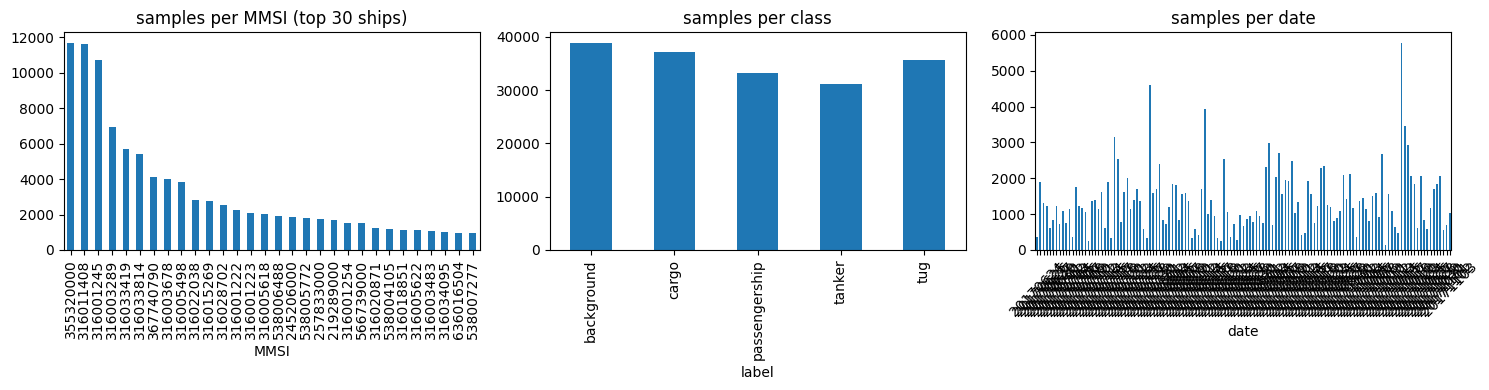

MMSI sample stats:
count      222.000000
mean       617.373874
std       1563.565762
min          2.000000
25%        100.750000
50%        158.000000
75%        330.000000
max      11703.000000
dtype: float64


In [3]:
# Samples per ship (MMSI) and per class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

per_mmsi = samples_per_mmsi(meta)
per_mmsi.head(30).plot(kind='bar', ax=axes[0], title='samples per MMSI (top 30 ships)')
axes[0].set_xlabel('MMSI')

meta.groupby('label').size().plot(kind='bar', ax=axes[1], title='samples per class')

meta.groupby('date').size().sort_index().plot(kind='bar', ax=axes[2], title='samples per date')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('MMSI sample stats:')
print(per_mmsi.describe())

In [4]:
# Official IEEE splits: MMSI appearing in more than one split (LEAKAGE RISK)
overlap = mmsi_split_overlap(meta)
leak = overlap[overlap['n_splits'] > 1].sort_values(['scenario', 'n_rows'], ascending=False)
print('MMSI with rows in >1 official split (per scenario):', len(leak))
leak.head(20)

MMSI with rows in >1 official split (per scenario): 302


,scenario,MMSI,splits,n_splits,n_rows,labels
212,inclusion_4000_exclusion_6000,0,"test,train,validation",3,13096,background
261,inclusion_4000_exclusion_6000,355320000,"test,train,validation",3,5945,tanker
225,inclusion_4000_exclusion_6000,316001245,"test,train,validation",3,5656,passengership
242,inclusion_4000_exclusion_6000,316011408,"test,train,validation",3,3666,passengership
252,inclusion_4000_exclusion_6000,316033419,"test,train,validation",3,2307,cargo
253,inclusion_4000_exclusion_6000,316033814,"test,train,validation",3,2029,cargo
228,inclusion_4000_exclusion_6000,316003289,"test,train,validation",3,1801,cargo
271,inclusion_4000_exclusion_6000,367740790,"test,train,validation",3,1753,tanker
247,inclusion_4000_exclusion_6000,316022038,"test,train,validation",3,1351,tug
223,inclusion_4000_exclusion_6000,316001222,"test,train,validation",3,1346,tug


In [5]:
# Cross-scenario: same MMSI in multiple distance bands
xscen = cross_scenario_mmsi(meta)
print('MMSI in multiple scenarios:', len(xscen))
xscen.head(20)

MMSI in multiple scenarios: 57


,MMSI,n_scenarios,scenarios,n_rows
0,0,3,"inclusion_2000_exclusion_4000,inclusion_3000_e...",38908
1,311000131,2,"inclusion_3000_exclusion_5000,inclusion_4000_e...",217
2,316001222,3,"inclusion_2000_exclusion_4000,inclusion_3000_e...",2251
3,316001223,3,"inclusion_2000_exclusion_4000,inclusion_3000_e...",2098
4,316001245,2,"inclusion_3000_exclusion_5000,inclusion_4000_e...",10754
5,316002059,2,"inclusion_2000_exclusion_4000,inclusion_4000_e...",485
6,316003289,3,"inclusion_2000_exclusion_4000,inclusion_3000_e...",6948
7,316003483,3,"inclusion_2000_exclusion_4000,inclusion_3000_e...",1083
8,316003678,3,"inclusion_2000_exclusion_4000,inclusion_3000_e...",4008
9,316005416,3,"inclusion_2000_exclusion_4000,inclusion_3000_e...",935


In [6]:
# Session-level: sub_init shared across splits (recording/session leakage)
sess = meta.groupby(['scenario', 'sub_init'])['split'].nunique().reset_index(name='n_splits')
sess_leak = sess[sess['n_splits'] > 1]
print('sub_init sessions spanning >1 official split:', len(sess_leak))
sess_leak.head(20)

sub_init sessions spanning >1 official split: 5969


,scenario,sub_init,n_splits
0,inclusion_2000_exclusion_4000,0,3
1,inclusion_2000_exclusion_4000,1,3
2,inclusion_2000_exclusion_4000,2,3
3,inclusion_2000_exclusion_4000,3,3
4,inclusion_2000_exclusion_4000,4,3
5,inclusion_2000_exclusion_4000,5,3
6,inclusion_2000_exclusion_4000,6,3
7,inclusion_2000_exclusion_4000,7,3
8,inclusion_2000_exclusion_4000,8,3
9,inclusion_2000_exclusion_4000,9,3


In [7]:
# Join SHA256 duplicates from quality report
if QUALITY.exists():
    meta_q = join_quality_report(meta, QUALITY)
    n_dup = int(meta_q['duplicate_of'].notna().sum())
    n_missing = int(meta_q['sha256'].isna().sum())
    print('rows with duplicate_of:', n_dup)
    print('rows missing quality join:', n_missing)

    # duplicates across different labels or splits
    dup_rows = meta_q[meta_q['duplicate_of'].notna()].copy()
    if not dup_rows.empty:
        canon = meta_q.dropna(subset=['sha256']).drop_duplicates('sha256', keep='first')
        canon_map = canon.set_index('sha256')[['label', 'split', 'scenario', 'MMSI', 'file_path']]
        dup_rows = dup_rows.merge(
            canon_map,
            left_on='sha256',
            right_index=True,
            suffixes=('', '_canonical'),
        )
        cross_label = dup_rows[dup_rows['label'] != dup_rows['label_canonical']]
        cross_split = dup_rows[dup_rows['split'] != dup_rows['split_canonical']]
        print('duplicate pairs with different label:', len(cross_label))
        print('duplicate pairs with different split:', len(cross_split))
        display(cross_split.head(10)[['file_path', 'file_path_canonical', 'label', 'label_canonical', 'split', 'split_canonical', 'MMSI']])
else:
    meta_q = meta.copy()
    print('Quality report not found — run scripts/verify/verify_audio.py first')

rows with duplicate_of: 0
rows missing quality join: 175965


In [8]:
# Write inspection reports (no train/val/test assignment)
META_OUT.mkdir(parents=True, exist_ok=True)

overlap.to_csv(META_OUT / 'vtuad_mmsi_split_overlap.csv', index=False)
xscen.to_csv(META_OUT / 'vtuad_mmsi_cross_scenario.csv', index=False)
sess_leak.to_csv(META_OUT / 'vtuad_session_split_leakage.csv', index=False)

report = {
    'dataset': 'VTUAD',
    'metadata_rows': int(len(meta)),
    'unique_MMSI_ships': int(meta.loc[meta['label'] != 'background', 'MMSI'].nunique()),
    'MMSI_in_multiple_official_splits': int(len(leak)),
    'MMSI_in_multiple_scenarios': int(len(xscen)),
    'sub_init_in_multiple_splits': int(len(sess_leak)),
    'notes': (
        'IEEE VTUAD ships pre-defined train/validation/test folders per scenario. '
        'Investigate MMSI/session overlap before adopting random 80/10/10 splits. '
        'Do not train models in this notebook.'
    ),
}
with open(META_OUT / 'vtuad_leakage_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2)

print('Wrote:')
for p in [
    'vtuad_mmsi_split_overlap.csv',
    'vtuad_mmsi_cross_scenario.csv',
    'vtuad_session_split_leakage.csv',
    'vtuad_leakage_report.json',
]:
    print(' ', META_OUT / p)
print(json.dumps(report, indent=2))

Wrote:
  D:\TinyShip-Finger\data\metadata\vtuad_mmsi_split_overlap.csv
  D:\TinyShip-Finger\data\metadata\vtuad_mmsi_cross_scenario.csv
  D:\TinyShip-Finger\data\metadata\vtuad_session_split_leakage.csv
  D:\TinyShip-Finger\data\metadata\vtuad_leakage_report.json
{
  "dataset": "VTUAD",
  "metadata_rows": 175965,
  "unique_MMSI_ships": 222,
  "MMSI_in_multiple_official_splits": 302,
  "MMSI_in_multiple_scenarios": 57,
  "sub_init_in_multiple_splits": 5969,
  "notes": "IEEE VTUAD ships pre-defined train/validation/test folders per scenario. Investigate MMSI/session overlap before adopting random 80/10/10 splits. Do not train models in this notebook."
}


## Next steps (after this notebook)

1. Choose split protocol: ship-group (MMSI), session-group (`sub_init`), temporal (`date`), or cross-domain
2. Build unified manifest: `python scripts/prepare/build_vtuad_manifest.py`
3. Only then: standardize audio + ShipNN reproduction baseline

**Do not** use a naive random clip split if MMSI/session leakage is confirmed above.